# **Part 2: Calculus in Neuroscience**

**Introduction**
Despite the immense complexity of the brain, mathematical modelling has allowed for major advances to be made towards understanding behaviour, consciousness and disease. Mathematical models can be used to describe processes from the level of single cell voltage dynamics, through emergent behaviour of neural networks to activity patterns in tissue level models. Underlying nearly all of these models are differential equations describing how various quantities (e.g. voltage, firing rate) change in time and space. This lecture introduces some of the mathematical tools needed to understand and analyse solutions of these models. We will see how to describe neural systems using differential equations.


## **1. Differential Equations in Neuroscience**

Differential equations are mathematical tools for describing how quantities change over time. In neuroscience, they're essential for modeling processes like voltage changes in a neuron, the decay of a synaptic current, or the evolution of neural population activity.

###  **What is a Differential Equation?**

A **differential equation** gives a rule for how a variable (like voltage or population size) changes. It doesn’t directly tell you the value of that variable — it tells you how it’s changing right now.

In its simplest form:
$$
\frac{dy}{dt} = f(y, t)
$$

This means “the rate of change of $y$ with respect to time equals some function of $y$ and $t$.”


If we consider a single quantity $u(t)$ that depends only on time then its evolution is governed by an **ordinary differential equation** (ODE). Here $t$ is an **independent** variable and $u$ is the **dependent** variable. If $u$ depends two or more variables, say $u(x,t)$ then we have a **partial differential equation** (PDE).

The **order** of a differential equation is the order of the highest derivative in the equation.

A differential equation of the dependent variable $u$ is said to be **linear** if the only $u$-dependent terms are $u$ itself and derivatives of $u$ and also
$u$ and its derivatives do not appear multiplied together. If a differential equation does not satisfy these conditions, it is said to be **nonlinear**.

E.g.
 $$\frac{dN}{dt}=aN$$

$$LQ′′+RQ′+\frac{1}{C}Q=E(t)$$

$$C \frac{dV}{dt}=V^2+I$$  

Typically, nonlinear equations are harder to solve than linear ones, but exhibit a much greater variety of behaviour.

A differential equation is autonomous if it does not depend explicitly on the independent variables.


### **Why This Matters**

Neural systems are dynamic — they are constantly changing. Rather than working with static values, we model how a system evolves:

- A neuron’s voltage integrating input over time
- A neurotransmitter concentration decaying after a release
- A population of neurons interacting over time

Differential equations let us express these kinds of systems precisely.

### **Population Growth**

Consider the expression for unrestricted population growth

$$
\frac{dN}{dt}=aN,
$$

where  $N=N(t)$  is the size of a given population,  $t$  is time and  $a$  is a parameter describing the growth rate.

The derivative  $\frac{dN}{dt}$  refers to the rate of change of  $N$ as  $t$  is varied, i.e. how is the population size going to change over time. On the right-hand side of the equation, we have an expression that prescribes that change. Assuming a positive initial population  $N(0)>0$ , if  $a$  is positive, our rate of change  $\frac{dN}{dt}$  will be positive, i.e. the population size is going to increase. If  $a$  is a negative, the rate of change  $\frac{dN}{dt}$  will be negative and the population size will decrease. Notice that there is also a  $N$  on the right-hand side of the equation. So, if  $N$ is small, the amount the population increases/decreases by is also going to be small, but the larger  $N$  gets the larger increase/decrease will become.

It may help to think about this in a discretised manner, e.g. how much do we expect the population to increase each year. \\
- Imagine the population of a particular town is $10,000$ and it increases by  $0.1N$  each year.
- The change in population size this year will be  $0.1×10000=1000$ , so next year the population size will be $11,000$.
- Now applying the same logic, the population in two years time will be  $11000+0.1×11000=12100$ .
- Below is a piece of code to apply this same logic to compute the population size for the next 25 years.

Year    dN/dt     N
1       1000      11000
2       1100      12100
3       1210      13310
4       1331      14641
5       1464      16105
6       1611      17716
7       1772      19487
8       1949      21436
9       2144      23579
10      2358      25937
11      2594      28531
12      2853      31384
13      3138      34523
14      3452      37975
15      3797      41772
16      4177      45950
17      4595      50545
18      5054      55599
19      5560      61159
20      6116      67275
21      6727      74002
22      7400      81403
23      8140      89543
24      8954      98497
25      9850      108347


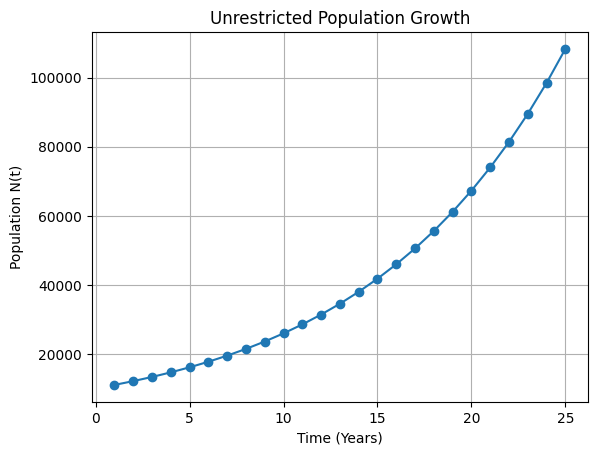

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10000        # Initial population
a = 0.1          # Growth rate
years = 25       # Number of steps

# Lists to store values for plotting
time_points = []
population = []

print('Year   ', 'dN/dt    ', 'N')

for t in range(1, years + 1):
    dN = a * N
    print(f"{t:<7} {round(dN):<9} {round(N + dN)}")
    N = N + dN
    time_points.append(t)
    population.append(N)

# Plotting
plt.plot(time_points, population, marker='o')
plt.title("Unrestricted Population Growth")
plt.xlabel("Time (Years)")
plt.ylabel("Population N(t)")
plt.grid(True)
plt.show()


**Exercise 1**: What happens if we change $a$ to be negative?

### **Exponential Decay**
Many signals in the brain fade away over time — such as a synaptic current after a spike. This can be described by:
$$
\frac{dI}{dt}=−λI
$$

Here, the current  $I$  shrinks over time at a rate proportional to its current value.  $λ$  is a constant that controls how quickly it decays.

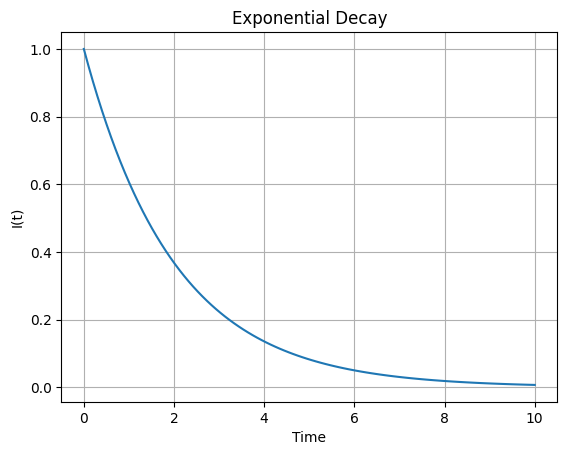

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
I0 = 1.0
lmbda = 0.5
t = np.linspace(0, 10, 100)
I = I0 * np.exp(-lmbda * t)

# Plot
plt.plot(t, I)
plt.title("Exponential Decay")
plt.xlabel("Time")
plt.ylabel("I(t)")
plt.grid(True)
plt.show()


**Exercise 2**: What happens if we change  $\lambda$ to be large? Will the current decay faster or slower?

The **state** of the system at time $t$ is the value of all dependent variables at that time. We want to know how the state evolves from a given initial state (this is the **solution** of the system). All of the equations above are **deterministic** so that, given the initial state of the system, the differential equation determines the state of the system at all later times.

Sometimes differential equations can be solved analytically to find an expression for the state variables as functions of time. There are further tutorials regarding solving differential equations analytically below:
-  [Ordinary Differential Equations Examples](https://https://mathinsight.org/ordinary_differential_equation_introduction_examples)
- [Basics of Differential Equations](https://https://math.libretexts.org/Courses/Monroe_Community_College/MTH_211_Calculus_II/Chapter_8%3A_Introduction_to_Differential_Equations/8.1%3A_Basics_of_Differential_Equations)


Within this lecture, however, we consider how to solve differential equations numerically, using the Euler and the Runge-Kutta methods.


##  **2. Numerical Methods for Solving Differential Equations**

Most real-world differential equations can’t be solved with a neat formula. Instead, we use **numerical methods** to simulate them step by step and help **approximate** their solutions.

This section introduces the **Euler** and **Runge-Kutta  method**, two of the more common numerical solvers. You’ll learn how to use it to simulate how variables like voltage or population change over time.



### **Euler's Method**

Euler's method is the simplest numerical method for estimating the solution of a differential equation. Similar to when we *discretised* the equation for unrestricted population growth and asked what the population increase was each year, Euler's method takes small time steps and computes the increase at each time step. The smaller the time step is, the more accurate the solution.
To approximately solve a differential equation

$$\frac{dy}{dx}= f(x, y)$$

with $y(x_0)=y_0$ (initial condition) and step size $Δx$, approximate the value of $y$ at
$x_1 = x_0 +Δx$ by $y_1 = y_0 + Δx f(x_0, y_0)$ where $f(x_0, y_0)$ is the derivative of $y$ at $(x_0, y_0)$.

![alt text](http://drive.google.com/uc?export=view&id=1_AQOV1BDrkm1n4TalYC9ed7rzM_e2yW7)


Repeating this for further steps,
$$y_{n+1} = y_n + Δx f(x_n,y_n)$$

is the approximate value of $y(x_0 + nΔx)$.

![alt text](http://drive.google.com/uc?export=view&id=1DsriNIDtVVKqQYqDMD9qabbx8YOMM0TK)


For the model of unrestricted population growth, the Euler method is defined as
 $$N_{n+1} = N_n + \Delta t \times a N_n,$$

where $\Delta t$ is the length of the time step we take.


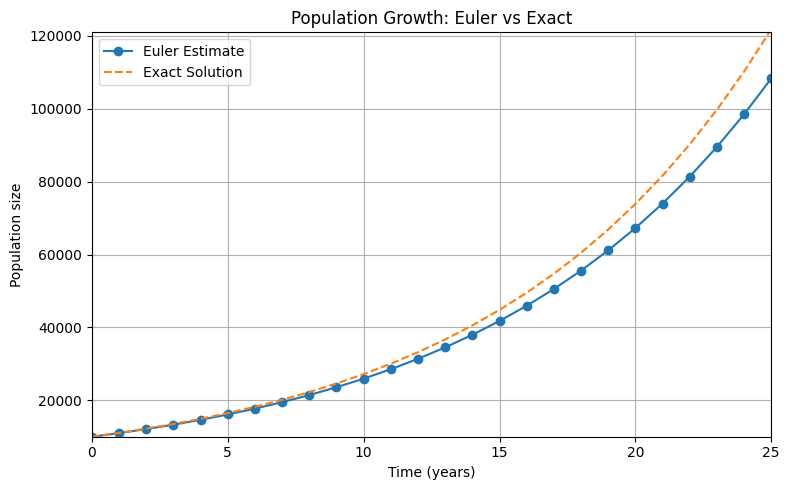

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation
def dNdt(a, x):
    return a * x

# Parameters
N0 = 10000
a = 0.1
dt = 1
t_est = np.arange(0, 25 + dt, dt)  # time points

# Euler's method
N_est = np.zeros(t_est.size)
N_est[0] = N0
for j in range(len(t_est) - 1):
    N_est[j + 1] = N_est[j] + dt * dNdt(a, N_est[j])

# Analytical solution
N_exact = N0 * np.exp(a * t_est)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t_est, N_est, label='Euler Estimate', marker='o')
plt.plot(t_est, N_exact, label='Exact Solution', linestyle='--')
plt.xlabel('Time (years)')
plt.ylabel('Population size')
plt.title('Population Growth: Euler vs Exact')
plt.axis([0, 25, N0, 121000])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Examining the graph, we see that the estimated solution underestimates the true solution and that it becomes more and more inaccurate as time increases.

**Exercise 3**: Change the step size to $0.1sec$ and run the simulation again. What do you observe?

### **Runge-Kutta method**
    
Unlike the Euler's Method, which calculates one slope at an interval, the Runge-Kutta calculates four different slopes and uses them as weighted averages.  We can improve the accuracy of our numerical solver by including higher order terms. However, higher-order methods require more calculations and function evaluations, and as such, will take longer to run. In practice, a good balance is achieved by the fourth order Runge–Kutta method. Instead of simply using our current population size to estimate, say next years population, we use estimates throughout the time interval (the year) to determine our estimate. The solution at each time point is computed as follows:
   $$x_{n+1} = x_n + \frac{1}{6}(k_1+2k_2+2k_3+k_4)$$

  where
  $$k_1=\Delta t f(x_n)$$
  $$k_2=\Delta t f(x_n+\frac{1}{2}k_1)$$
  $$k_3=\Delta t f(x_n+\frac{1}{2}k_2)$$
  $$k_4=\Delta t f(x_n+k_3)$$
    
  ![alt text](http://drive.google.com/uc?export=view&id=1v692EwbIrKkewJMsv2dyrAwq7OpqFORK)

 See [Harold Serrano's blog post](https://www.haroldserrano.com/blog/visualizing-the-runge-kutta-method) for a nice visualisation of the Runge-Kutta method.

As we did for Euler's method, we set up the Runge-Kutta method and iterate over time to compute the estimated solution.


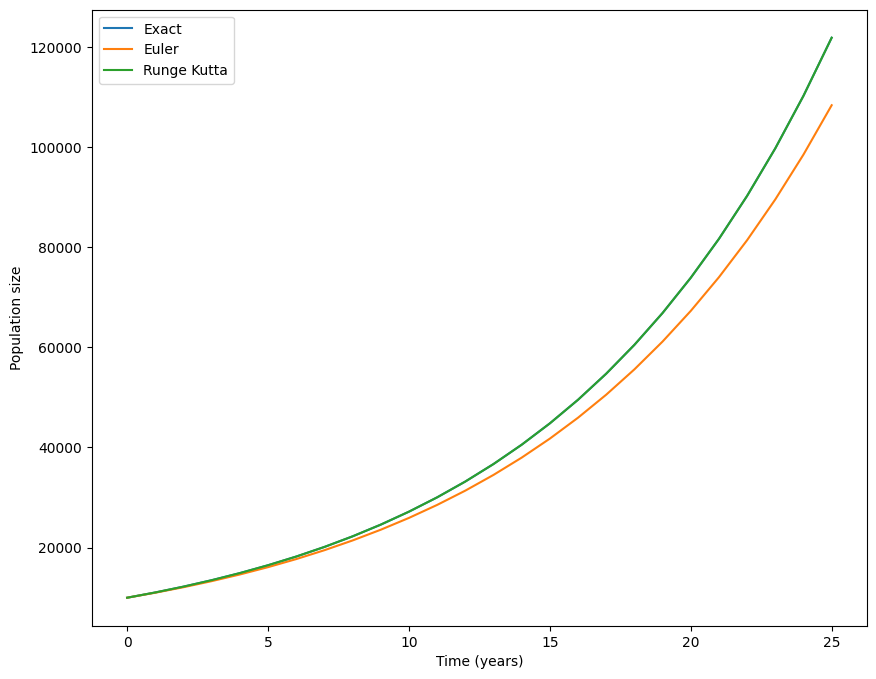

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation
def dNdt(a, x):
    return a * x

# Parameters
N0 = 10000
a = 0.1
dt = 1
t_est = np.arange(0, 25 + dt, dt)  # time points

# Euler's method
N_est = np.zeros(t_est.size)
N_est[0] = N0
for j in range(len(t_est) - 1):
    N_est[j + 1] = N_est[j] + dt * dNdt(a, N_est[j])

# Analytical solution
N_exact = N0 * np.exp(a * t_est)

t_RK = np.arange(0,25+dt,dt)
N_RK = np.zeros(t_RK.size)
N_RK[0] = N0
for n in range(len(t_RK)-1):
    k1 = dt*dNdt(a,N_RK[n])
    k2 = dt*dNdt(a,N_RK[n]+0.5*k1)
    k3 = dt*dNdt(a,N_RK[n]+0.5*k2)
    k4 = dt*dNdt(a,N_RK[n]+k3)
    N_RK[n+1] = N_RK[n] + (k1 + 2*k2 + 2*k3 + k4)/6



plt.figure(figsize=((10,8)))
plt.plot(t_est,N_exact,label='Exact')
plt.plot(t_est,N_est,label='Euler')
plt.plot(t_RK,N_RK,label='Runge Kutta')

plt.xlabel('Time (years)')
plt.ylabel('Population size')
plt.legend()
plt.show()

**Exercise 4**: Change the step size to $2sec$ and run the simulation again. What do you observe?


##  **3. Leaky Integrate-and-Fire (LIF) Neuron Model**

 The leaky integrate and fire model is fundamentally a differential equation that describes how a neuron's membrane potential changes over time. A neuron receives many incoming signals from other neurons throughout the day. It needs to decide: "Should I send out my own signal based on all this input I'm getting?"

It’s based on a simple differential equation that captures how voltage (membrane potential) changes in response to input current and decays back to rest.

The leaky integrate and fire model breaks this down into three simple parts:

- **1. Integrate**: The neuron collects all the incoming signals, like adding them up in a running total. \\

 -  *Imagine it's like a bucket collecting raindrops.*

- **2. Leaky**: But the neuron doesn't remember everything forever - the signals gradually fade away over time.
 - *This is like the bucket having a small hole in the bottom, so old raindrops slowly leak out.*

- **3. Fire**: When enough signal builds up to cross a certain threshold, the neuron suddenly sends out its own strong signal to other neurons.
 - *This is like the bucket overflowing - when it happens, the neuron "fires" and then empties out to start over.*

The mathematical equation captures this balance between charge flowing in (from other neurons), charge leaking out (natural membrane properties), and the threshold-crossing event that triggers firing. It's essentially modeling the neuron as a simple electrical circuit with a capacitor that can discharge when it gets full enough. \\
This model strips away much of the biological complexity but captures the essential computational behavior of how neurons integrate inputs over time to make firing decisions.


### **Model Equations**

This model describes the voltage of a neuron integrating incoming current with leakage.

$$
\tau_m \frac{dV}{dt} = -(V - V_{rest}) + \frac{I(t)}{g_L}
$$

Where
- $V$: Neuronal membrane potential; $\frac{dV}{dt}$ : The change in membrane potential
- $V_{rest}$: The resting membrane potential, the voltage when the neuron is not receiving input.
- $g_L$: The leak conductance, measures the ease with which an electric current passes.
- $I$: The external current being applied to the neuron.
- $\tau_m$: The membrane time constant, representing how quickly the membrane potential changes.


In this deterministic model, the membrane potential of the neuron increases due to the applied current (scaled according to the membrane conductance) and reduces according to how much it deviates from the resting potential.
\
The model equation tracks the change in $V$ over time, until it reaches the *firing threshold*, at which point the neuron "fires" a spike. Immediately after firing a spike, the voltage the membrane potential is reset.
\
This differential equation doesn't have a simple algebraic solution when the input current $I$ changes in complex ways over time. So we use numerical integration (Euler or Runge-Kutta nethods, for example)- we approximate the solution by taking tiny time steps and calculating how the voltage changes in each small interval.

In [ ]:
# This function simulates the LIF neuron for a given input current 'I'.
def lif_sim(I=1.0):
    """
    Simulates the membrane potential of a Leaky Integrate-and-Fire neuron
    over time and plots the result.

    Args:
        I (float): The constant input current applied to the neuron (in nA).
                   This parameter is controlled by the interactive slider.
    """
    # --- Model Parameters ---
    # These parameters define the properties of the simulated neuron.
    tau_m = 10  # ms             # Membrane time constant: Controls how quickly the voltage changes.
    V_rest = -65  # mV           # Resting membrane potential: The voltage the neuron returns to when inactive.
    V_th = -50  # mV             # Firing threshold: The voltage level at which the neuron generates a spike.
    V_reset = -70  # mV          # Reset voltage: The voltage the neuron is reset to immediately after firing a spike.
    R = 10  # MΩ               # Membrane resistance: Relates current to voltage change (V = IR).
                                 # Used here in the current input term (R * I).

    # --- Simulation Setup ---
    # These parameters define the time steps and duration of the simulation.
    dt = 0.1                     # Time step size (in ms): Smaller steps provide more accuracy but take longer.
    T = 100  # ms                # Total simulation duration (in ms).
    steps = int(T / dt)          # Number of discrete time steps: Calculated from total time and step size.

    # --- Initialization ---
    # Prepare arrays to store the simulation data.
    # Array to store the membrane potential (voltage) at each time step.
    # It's initialized with zeros, but the first value is immediately set.
    V = np.zeros(steps)
    V[0] = V_rest                # Set the initial membrane potential to the resting potential at the start (time = 0).

    # --- Simulation Loop (Numerical Integration) ---
    # Iterate through each time step to calculate the membrane potential over time.
    # We start from the second step (index 1) because the first step (index 0) is the initial condition.
    for t in range(1, steps):
        # --- Calculate Change in Voltage (dV) ---
        # This is the core LIF differential equation integrated using Euler's method.
        # The equation describes how the voltage changes based on:
        # 1. The 'leak' term (-(V[t-1] - V_rest)): Drives the voltage back towards V_rest.
        # 2. The 'input current' term (R * I): Increases the voltage based on applied current and membrane resistance.
        # The rate of change (dV/dt) is multiplied by dt to get the change in voltage over one time step.
        dV = dt / tau_m * (-(V[t-1] - V_rest) + R * I)

        # --- Update Voltage ---
        # Add the calculated change (dV) to the voltage from the previous time step.
        # This is the explicit Euler step: V(t) = V(t-dt) + dt * dV/dt
        V[t] = V[t-1] + dV

        # --- Spike and Reset Condition ---
        # Check if the membrane potential has reached or exceeded the firing threshold.
        if V[t] >= V_th:
            # If the threshold is reached, the neuron 'fires' a spike.
            # In this simplified model, firing immediately resets the membrane potential
            # to the reset voltage (V_reset).
            V[t] = V_reset  # Spike and reset the voltage for the next time step.

    # --- Plotting Results ---
    # After the loop finishes, plot the calculated membrane potential over time.
    # Create a time vector corresponding to each simulation step for the x-axis.
    time = np.linspace(0, T, steps)

    # Create a figure and axes for the plot.
    plt.figure(figsize=(10, 4)) # Set the figure size (width, height) in inches.

    # Plot the membrane potential (V) against time.
    plt.plot(time, V)

    # Set the title of the plot, including the value of the input current.
    # Using an f-string for easy formatting.
    plt.title(f"LIF Neuron Simulation: Input Current = {I:.1f} nA")

    # Set the label for the x-axis (Time).
    plt.xlabel("Time (ms)")

    # Set the label for the y-axis (Membrane Potential).
    plt.ylabel("Membrane Potential (mV)")

    # Add a grid to the plot for easier reading of values.
    plt.grid(True)

    # Display the plot.
    plt.show()

# --- Create Interactive Widget ---
# Link the 'lif_sim' function to an interactive control.
# This creates a slider widget that controls the 'I' parameter of the 'lif_sim' function.
# When the slider's value changes, the 'lif_sim' function is automatically called with the new value,
# and the plot is updated.
interact(
    lif_sim,                       # The function to make interactive.
    I=FloatSlider(                 # Create a floating-point slider widget.
        value=1.5,                 # The initial value of the slider.
        min=0.0,                   # The minimum value of the slider.
        max=3.0,                   # The maximum value of the slider.
        step=0.1,                  # The increment/decrement step size of the slider.
        description='Input Current (nA)' # A label displayed next to the slider.
    )
)

interactive(children=(FloatSlider(value=1.5, description='Input Current (nA)', max=3.0), Output()), _dom_class…

<function __main__.lif_sim(I=1.0)>

**Question 5**: Run the simulation with a significantly smaller $dt$ (e.g., $0.01$). While the general behavior might look similar, note that the exact spike times or voltage peaks might be slightly different compared to the larger dt simulation.

**Question 6**: Modify the initial voltage $V[0]$ to something other than $V_{rest}$. See how the neuron's initial state affects the time it takes to reach the first spike.


## **4. Lotka-Volterra Model: Neural Population Dynamics**


The Lotka–Volterra equations,  are a pair of **coupled** first-order, non‑linear differential equations originally formulated by Alfred Lotka and Vito Volterra in the 1920s to describe rhythmic oscillations between predator and prey populations. Lotka-Volterra model is a classic example of how two interacting populations (like predator and prey) influence each other over time. In neuroscience, we can think of it as a simplified model of **excitatory and inhibitory populations**.




### **Model Equations**
$$
\frac{dx}{dt} = \alpha x - \beta xy \\
\frac{dy}{dt} = \delta xy - \gamma y
$$

$x(t)$ = prey population

$y(t)$ = predator population

$α$ = prey reproduction rate

$β$ = predation rate

$γ$ = predator death rate

$δ$ = efficiency of converting eaten prey into new predators


These equations produce continuous, periodic cycles where predator numbers lag behind prey numbers—classically visualized via time series or closed orbits in phase space.


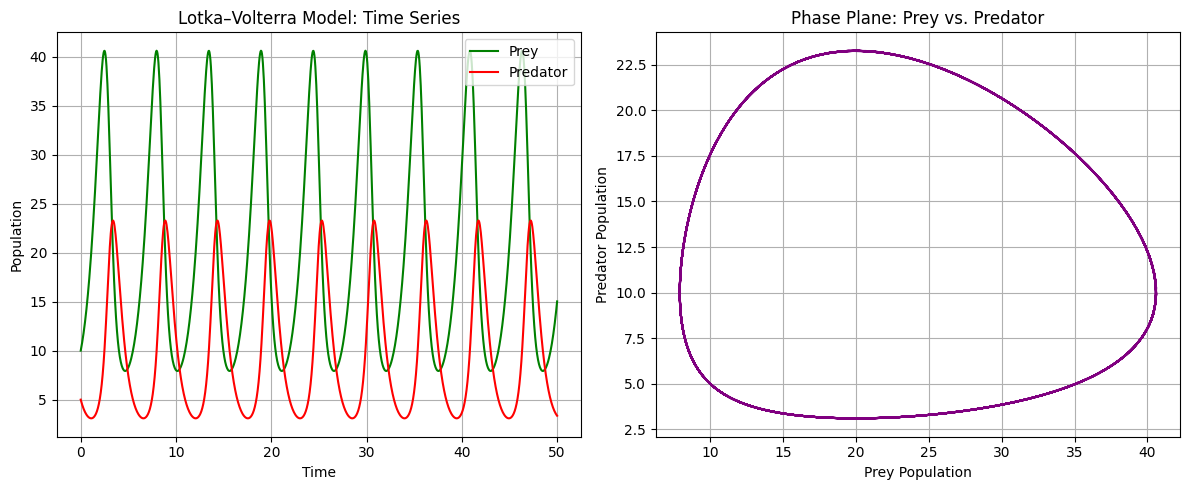

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the Lotka-Volterra equations
def lotka_volterra(X, t, alpha, beta, delta, gamma):
    x, y = X
    dxdt = alpha * x - beta * x * y       # Prey growth - predation
    dydt = delta * x * y - gamma * y      # Predator growth - death
    return [dxdt, dydt]

# Parameters
alpha = 1.0    # Prey birth rate
beta = 0.1     # Predation rate
delta = 0.075  # Predator reproduction efficiency
gamma = 1.5    # Predator death rate

# Initial conditions: [prey, predator]
X0 = [10, 5]

# Time grid
t = np.linspace(0, 50, 1000)

# Solve ODEs
solution = odeint(lotka_volterra, X0, t, args=(alpha, beta, delta, gamma))

# Plotting
plt.figure(figsize=(12, 5))

# Time series plot
plt.subplot(1, 2, 1)
plt.plot(t, solution[:, 0], label='Prey', color='green')
plt.plot(t, solution[:, 1], label='Predator', color='red')
plt.title('Lotka–Volterra Model: Time Series')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True)

# Phase plane plot
plt.subplot(1, 2, 2)
plt.plot(solution[:, 0], solution[:, 1], color='purple')
plt.title('Phase Plane: Prey vs. Predator')
plt.xlabel('Prey Population')
plt.ylabel('Predator Population')
plt.grid(True)

plt.tight_layout()
plt.show()



Above is a simulation of a Lotka–Volterra system using standard parameters. The plots show:

- Time Series (Left): Oscillatory population dynamics of prey and predators over time.

- Phase Plane (Right): A closed loop indicating a stable limit cycle—typical of Lotka–Volterra systems.

This example demonstrates how the system doesn’t converge to a fixed point or diverge but instead cycles endlessly—an indication of neutral stability.

### **Applications in Computational Neuroscience**

Neuronal systems often consist of interacting populations with excitatory and inhibitory dynamics that mirror predator–prey interactions:

#### **Excitation–Inhibition Balance**

Excitatory neurons act like “prey”—they can proliferate activity via positive feedback.

Inhibitory neurons behave like “predators”—they suppress or regulate excitatory activity.

Lotka–Volterra-style models capture how the interplay between E and I populations can spontaneously oscillate and stabilize .

#### **Oscillatory Rhythms**

Neural rhythms (e.g., alpha, gamma) emerge from recurrent loops of excitation and inhibition.

Lotka–Volterra equations formalize such reciprocal interactions, predicting oscillation frequencies and phase lags similar to predator–prey systems.

#### **Modeling Population Dynamics & Control**

These models help simulate how neural networks respond to inputs, recover from disruptions, or exhibit phase-locked patterns (e.g., bursting, up/down states).

They allow parameter exploration—e.g., varying synaptic weight is akin to adjusting predation rate β, affecting oscillation amplitude or period.

#### **Advanced Extensions**

Researchers extend Lotka–Volterra frameworks into neural mass models or firing-rate networks, including stochastic or time-varying components.

Modern approaches like Neural ODEs also embed Lotka–Volterra dynamics into data-driven neural models

### **Excitatory–Inhibitory Neuron Dynamics via Lotka–Volterra**

 In the brain, excitatory neurons ($E$) promote neural activity, while inhibitory neurons ($I$) suppress it. The balance between these two types maintains stable brain function and is critical for preventing runaway excitation (e.g., seizures) or over-inhibition (e.g., comatose states).

We can adapt the Lotka–Volterra model like this:

$$\frac{𝑑𝐸}{𝑑𝑡}=𝑎𝐸−𝑏𝐸𝐼$$    (Excitatory dynamics)
$$\frac{𝑑𝐼}{𝑑𝑡}=𝑐𝐸𝐼−𝑑𝐼$$     (Inhibitory dynamics)

Where:
- $𝐸(𝑡)$: population activity of excitatory neurons
- $I(t)$: population activity of inhibitory neurons
- $𝑎$: intrinsic excitation (e.g., from external input or spontaneous activity)
- $𝑏$: inhibition of $E$ by $I$
- $𝑐$: activation of $I$ by $E$ (i.e., $E$ drives $I$)
- $𝑑$: decay or fatigue of inhibitory activity

#### **Biological Interpretation**
- Excitatory neurons increase activity on their own but are suppressed by inhibition.
- Inhibitory neurons are activated by excitatory input, but they also decay over time.
- This feedback loop is a fundamental circuit in cortical microcircuits (e.g., pyramidal-interneuron loop).



### **Stability Analysis**

Stability analysis determines what happens to a dynamical system (like our Lotka-Volterra model) when it is slightly perturbed from a steady state (equilibrium). Specifically, we ask:

"If the system is near a steady state, will it return to it, stay near it, or move away?"

**Step 1**: Find Equilibrium Points
Set the derivatives to zero:

$$
\frac{dE}{dt}​ =0
$$
$$
\frac{dI}{dt}=0
$$

Solve these equations to find the fixed points—values
($E^*,I^*$) where the system can remain indefinitely.

**Step 2**: Linearise the System   \\
Near a fixed point, approximate the nonlinear system with a linear one using a Jacobian matrix:

$$
J(E, I) =
\begin{bmatrix}
\frac{\partial f_E}{\partial E} & \frac{\partial f_E}{\partial I} \\
\frac{\partial f_I}{\partial E}  & \frac{\partial f_I}{\partial I}
\end{bmatrix}
\Bigg|_{(E^*, I^*)}
$$
   
Where $f_E$ and $f_I$  are the right-hand sides of the equations for $\frac{dE}{dt}$ and $\frac{dI}{dt}$.

**Step 3**: Analyse Eigenvalues of the Jacobian matrix \\
- If all eigenvalues have **negative real parts**, the equilibrium is *stable* (perturbations die out).

- If any eigenvalue has a **positive real part**, the equilibrium is *unstable* (perturbations grow).

- If eigenvalues are **purely imaginary**, the system may exhibit neutral stability or limit cycles.



Equilibrium point: E* = 1.25 , I* = 1.5
Jacobian matrix at (E*, I*):
 [[ 0.   -1.25]
 [ 1.2   0.  ]]
Eigenvalues: [0.+1.22474487j 0.-1.22474487j]
→ Marginally stable or oscillatory behavior


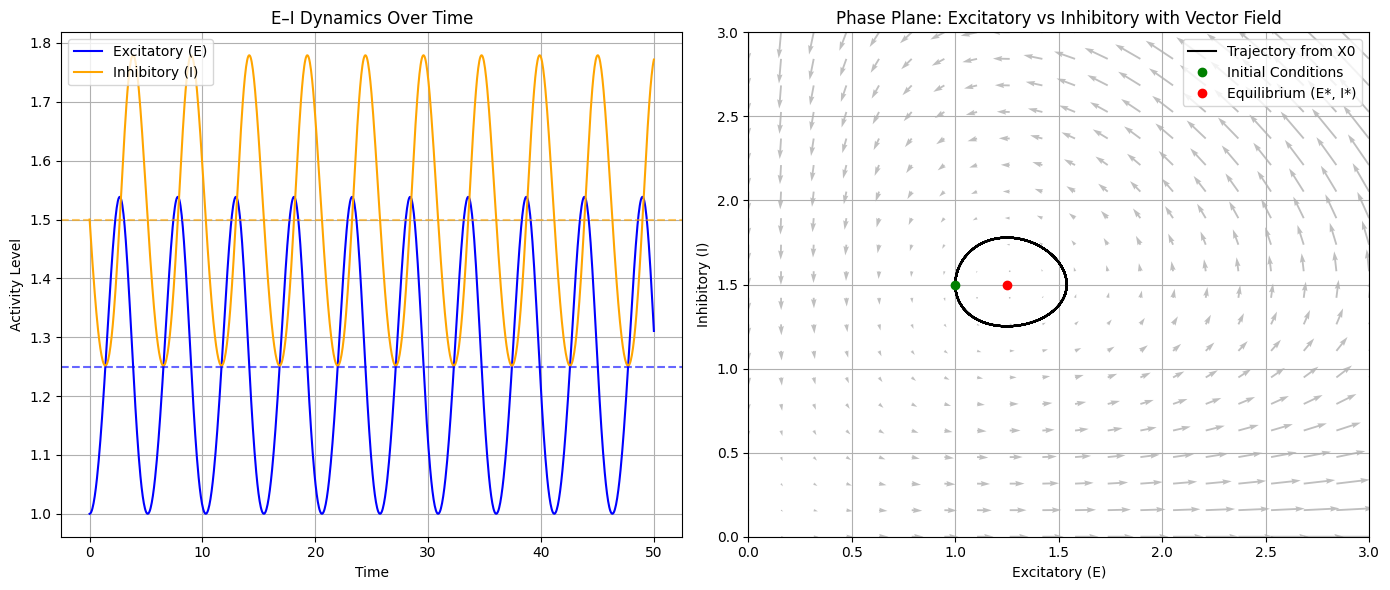

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from numpy.linalg import eig

# Define the E-I system (Lotka-Volterra style)
def ei_dynamics(X, t, a, b, c, d):
    E, I = X
    dEdt = a * E - b * E * I     # Excitatory growth - inhibition
    dIdt = c * E * I - d * I     # Inhibitory activation - decay
    return [dEdt, dIdt]

# Parameters
a = 1.5  # Excitatory self-activation
b = 1.0  # Inhibition of E by I
c = 0.8  # Excitation of I by E
d = 1.0  # Inhibitory decay

# Fixed point (non-zero equilibrium)
E_star = d / c
I_star = a / b

# Jacobian matrix at equilibrium
J = np.array([
    [a - b * I_star, -b * E_star],
    [c * I_star, c * E_star - d]
])

# Eigenvalues of the Jacobian
eigenvalues, _ = eig(J)

# Print results
print("Equilibrium point: E* =", E_star, ", I* =", I_star)
print("Jacobian matrix at (E*, I*):\n", J)
print("Eigenvalues:", eigenvalues)
if np.all(np.real(eigenvalues) < 0):
    print("→ Stable equilibrium")
elif np.any(np.real(eigenvalues) > 0):
    print("→ Unstable equilibrium")
else:
    print("→ Marginally stable or oscillatory behavior")

# Initial conditions and time
X0 = [1.0, 1.5]
t = np.linspace(0, 50, 1000)

# Integrate ODE
sol = odeint(ei_dynamics, X0, t, args=(a, b, c, d))

# Plotting
plt.figure(figsize=(14, 6))

# Time series plot
plt.subplot(1, 2, 1)
plt.plot(t, sol[:, 0], label='Excitatory (E)', color='blue')
plt.plot(t, sol[:, 1], label='Inhibitory (I)', color='orange')
plt.axhline(E_star, color='blue', linestyle='--', alpha=0.6)
plt.axhline(I_star, color='orange', linestyle='--', alpha=0.6)
plt.title('E–I Dynamics Over Time')
plt.xlabel('Time')
plt.ylabel('Activity Level')
plt.legend()
plt.grid(True)

# Phase plane plot with Vector Field
plt.subplot(1, 2, 2)

# Create a grid for the vector field
E_grid, I_grid = np.meshgrid(np.linspace(0, 3, 20), np.linspace(0, 3, 20)) # Adjust grid range as needed

# Calculate the derivatives at each point on the grid
dE_grid, dI_grid = ei_dynamics([E_grid, I_grid], 0, a, b, c, d)

# Plot the vector field
plt.quiver(E_grid, I_grid, dE_grid, dI_grid, color='gray', alpha=0.5)

# Plot the trajectory from the initial condition
plt.plot(sol[:, 0], sol[:, 1], color='black', label='Trajectory from X0')
plt.plot(X0[0], X0[1], 'go', label='Initial Conditions') # Mark initial conditions
plt.plot(E_star, I_star, 'ro', label='Equilibrium (E*, I*)') # Mark equilibrium point

plt.title('Phase Plane: Excitatory vs Inhibitory with Vector Field')
plt.xlabel('Excitatory (E)')
plt.ylabel('Inhibitory (I)')
plt.legend()
plt.grid(True)
plt.xlim([0, 3]) # Set plot limits for better visualization of the vector field
plt.ylim([0, 3])

plt.tight_layout()
plt.show()

**Question 7**: Change the value of $a$ to a larger positive number (e.g., a = 3.0). How does this affect the oscillations and the phase plane trajectory compared to the original value?

**Question 8**: Reduce the value of c (e.g., c = 0.2). If excitatory neurons are less effective at activating inhibitory neurons, what does this do to the balance between E and I? How does the system's behavior change?

**Question 9**: Keep the parameters the same but change the initial conditions X0 to a point closer to the equilibrium point (e.g., X0 = [E_star * 1.1, I_star * 0.9]). Does the trajectory still follow the same path or a different one?